***Estrutucuración del proyecto***

*Instalar y desplegar librerias*

In [52]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn plotly jupyter


In [53]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
# Utilidades
import warnings
warnings.filterwarnings('ignore')


*Leer archivos*

In [54]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
Permiso denegado (¿está abierto en Excel?): Noviembre-2025.xlsx
No encontrado: Marzo-2026.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Diciembre-

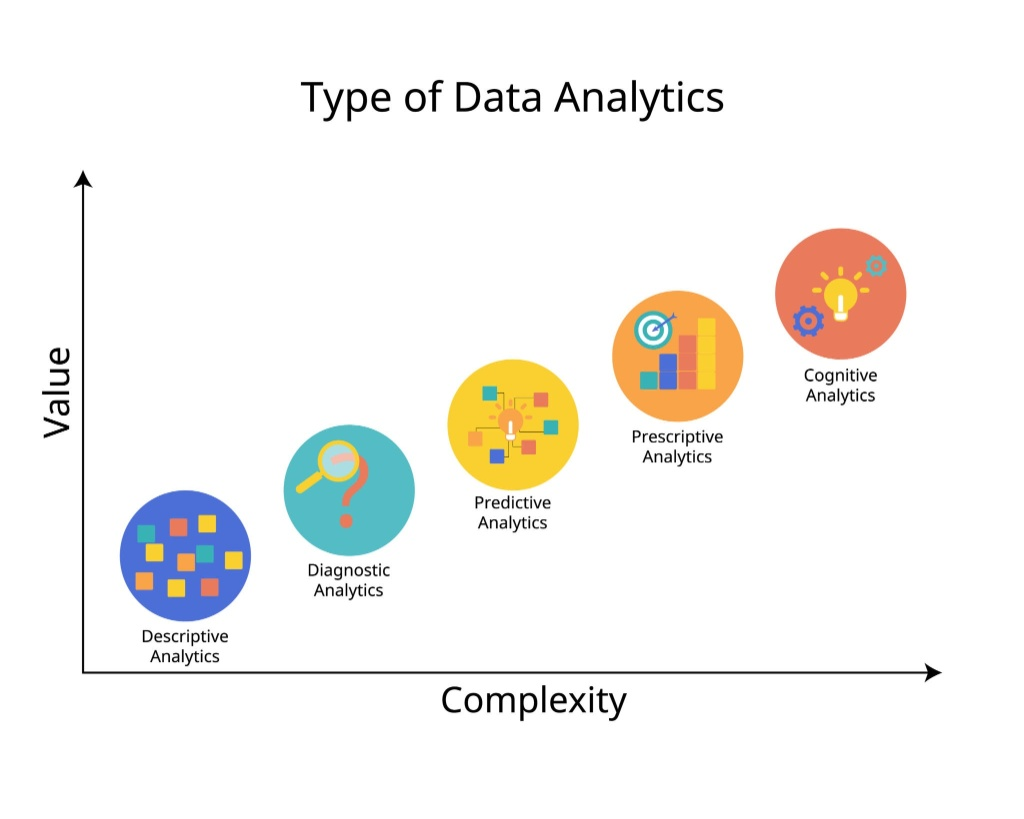

*Verificar fechas de los acrhivos*

In [55]:
col_fecha = "Fecha elaboración"
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")



Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28


*Crear un df unificado*

In [56]:
df_total = pd.concat(productos.values(), ignore_index=True)


*Concatenar df de ventas por lugar*

In [57]:

#Concatenar en caso de tener mas datos
CP_df=factura_lugar["CP-2025"]
Principal_df=factura_lugar["Principal-2025"]

#Poner el lugar en cada df
CP_df["Lugar"]="CP"
Principal_df["Lugar"]="Principal"

#Unificar todo en un solo df
df_place=pd.concat([CP_df,Principal_df],ignore_index=True)



*Ver que datos tiene cada df*

In [58]:
col1=set(df_total.columns)
col2=set(df_place.columns)

#Mirar intersescciones
print(col1 - col2)#Esta en  total
print(col2 - col1)#Esta en places
print(col2 & col1)#Esta en ambos


{'Consecutivo', 'Factura proveedor', 'Bodega', 'Impuesto Cargo 2', 'Fecha modificación', 'Fecha creación', 'Tipo de registro', 'Valor Impuesto Cargo 2', 'Nombre', 'Cantidad', 'Centro costo', 'Tipo transacción', 'Cargo en totales', 'Impuesto retención', 'Valor unitario', 'Número comprobante', 'Fecha vencimiento', 'Identificación Vendedor', 'Referencia fábrica', 'Correo electrónico', 'Observaciones', 'Nombre tercero', 'Forma pago', 'Impuesto cargo', 'Tasa de cambio', 'Sucursal', 'Descuento en totales', 'Tipo clasificación', 'Base AIU', 'Identificación', 'Valor desc.', 'Fecha elaboración', 'Valor Impuesto Cargo', 'Código', 'Base retención (ICA/IVA)', 'Nombre contacto', 'Nombre vendedor', 'Valor Impuesto Retención'}
{'Turno', 'Efectivo', 'Crédito', 'Pagos en línea', 'Vendedor', 'Tarjetas', 'Tipo de comprobante', 'Estado', 'Cliente', 'Fecha y hora', 'Lugar', 'Otros', 'Nro. de identificación', 'Nro. de comprobante'}
{'Total'}


*Adaptar datos por factura*

In [59]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Principal",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


*Poner fecha en formato datetime*

In [60]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


*Poner como se pago cada transacción y otras cosas*

In [61]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


In [62]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


In [88]:
ventas=df_ventas_producto_filtrado
ventas.rename(columns={"Fecha creación":"Fecha"},inplace=True)
ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento,Periodo
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal,2024-08
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal,2024-08
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal,2024-08
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal,2024-08
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal,2024-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29044,896.0,2026-02-02,16,Bowl Colombianito Mediana,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Nequí,FV-4,CP,2026-02
29045,896.0,2026-02-02,27,Ensalada Chefsito Grande,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Nequí,FV-4,CP,2026-02
29046,896.0,2026-02-02,79,Americano Mediano,Juan Jose Yara Vallejo,2.0,4166.66,666.67,9000.0,Nequí,FV-4,CP,2026-02
29047,896.0,2026-02-02,21025,Mexi,Juan Jose Yara Vallejo,1.0,18500.00,0.00,18500.0,Nequí,FV-4,CP,2026-02


In [89]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


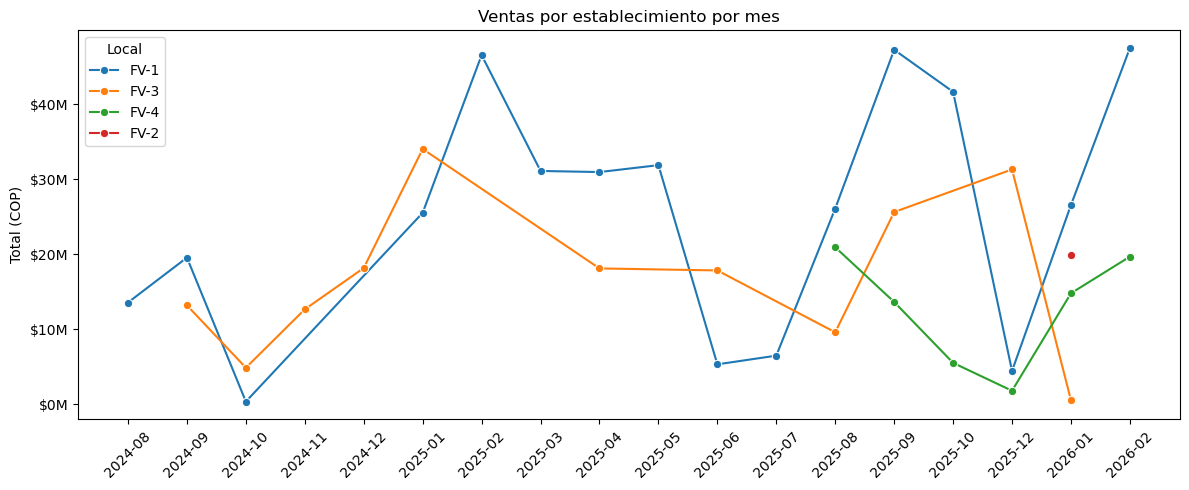

In [90]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


In [92]:
import pandas as pd
import plotly.express as px

# 1. Resumen de ventas
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)

# Convertir a string es vital para que no lo trate como fecha continua
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

# 2. Gráfico interactivo
fig = px.bar(
    resumen_mes, 
    x="Periodo", 
    y="Total",
    title="Análisis de Ventas por Periodo",
    labels={"Total": "Monto ($)", "Periodo": "Mes"},
    text_auto='.2s', 
    color_discrete_sequence=["steelblue"]
)

# 3. Personalización estética (Aquí forzamos que aparezcan todos los meses con datos)
fig.update_layout(
    xaxis_tickangle=-45,
    # ESTA LÍNEA ES LA QUE ELIMINA LOS HUECOS VACÍOS COMO DICIEMBRE:
    xaxis_type='category', 
    yaxis_tickformat="$.2s", # Cambiado a .2s para que el eje diga $80M en lugar de $80,000,000
    hovermode="x unified",
    template="plotly_white"
)

# 4. Mostrar el gráfico
fig.show()


In [83]:
import plotly.express as px

# 1. Preparación (Asegúrate de convertir el periodo a texto para evitar los huecos)
resumen_compras_mes = (
    compras
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

# 2. Gráfico
fig = px.bar(
    resumen_compras_mes, 
    x="Periodo", 
    y="Total",
    title="Total Compras por Periodo",
    color_discrete_sequence=["#CD5C5C"] # Rojo similar al de tu imagen
)

# 3. El truco para quitar los huecos y poner el formato $18M
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    # ESTA LÍNEA QUITA LOS HUECOS:
    xaxis_type='category', 
    # ESTA LÍNEA PONE EL FORMATO $18M:
    yaxis_tickformat="$.2s", 
    hovermode="x unified"
)

# Personalizar el texto al pasar el mouse
fig.update_traces(
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Total:</b> $%{y:,.0f}"
)

fig.show()


In [68]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-12   37505122.90      2227879.0  35277243.90
16  2026-01   61709036.00      6363951.0  55345085.00
17  2026-02   67204850.00   

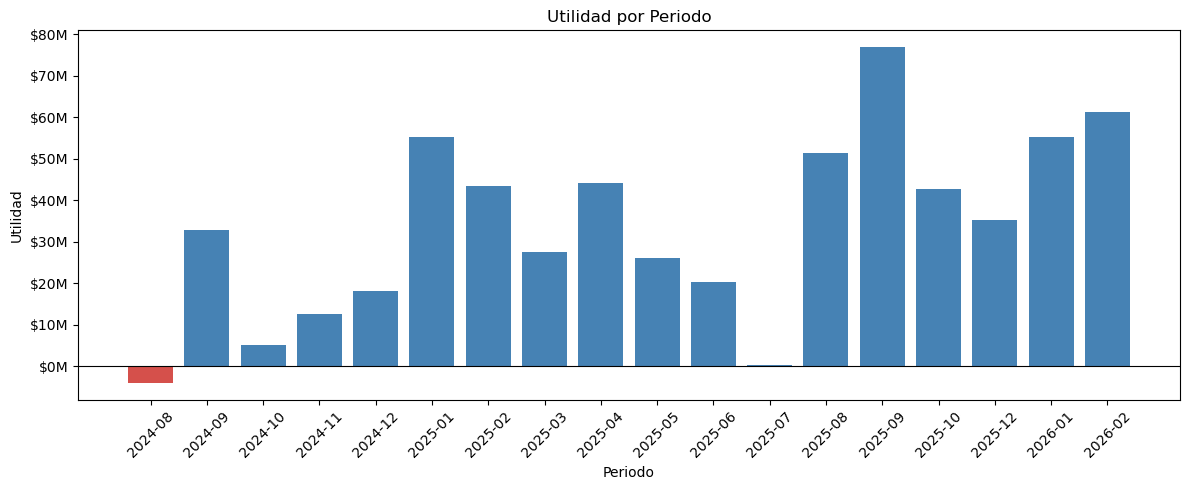

In [69]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


# Analisis productos



In [70]:
ventas_p=ventas[(ventas["Establecimiento"]=="Principal")&(ventas["Fecha"]>="2025-01-01")].sort_values("Fecha",ascending=True).reset_index()
dataset_p=ventas_p[["Fecha","Nombre","Cantidad","Total"]]


In [71]:
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones": x["Nombre"].count(),
    "cantidad_total": x["Cantidad"].sum(),
    "precio_promedio": x["Total"].sum() / x["Cantidad"].sum(),
    "Plata generada":x["Total"].sum()
    
})).sort_values("transacciones", ascending=False)


In [72]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)


import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",  # Los colores se asignan por cuadrante
    color_discrete_map={       # Colores estratégicos
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",   # Verde
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",    # Azul
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",    # Amarillo
        "BAJO DESEMPEÑO": "#e74c3c"                  # Rojo
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

# Ajustes estéticos finales
fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


In [ ]:
info_productos=info_productos.reset_index()


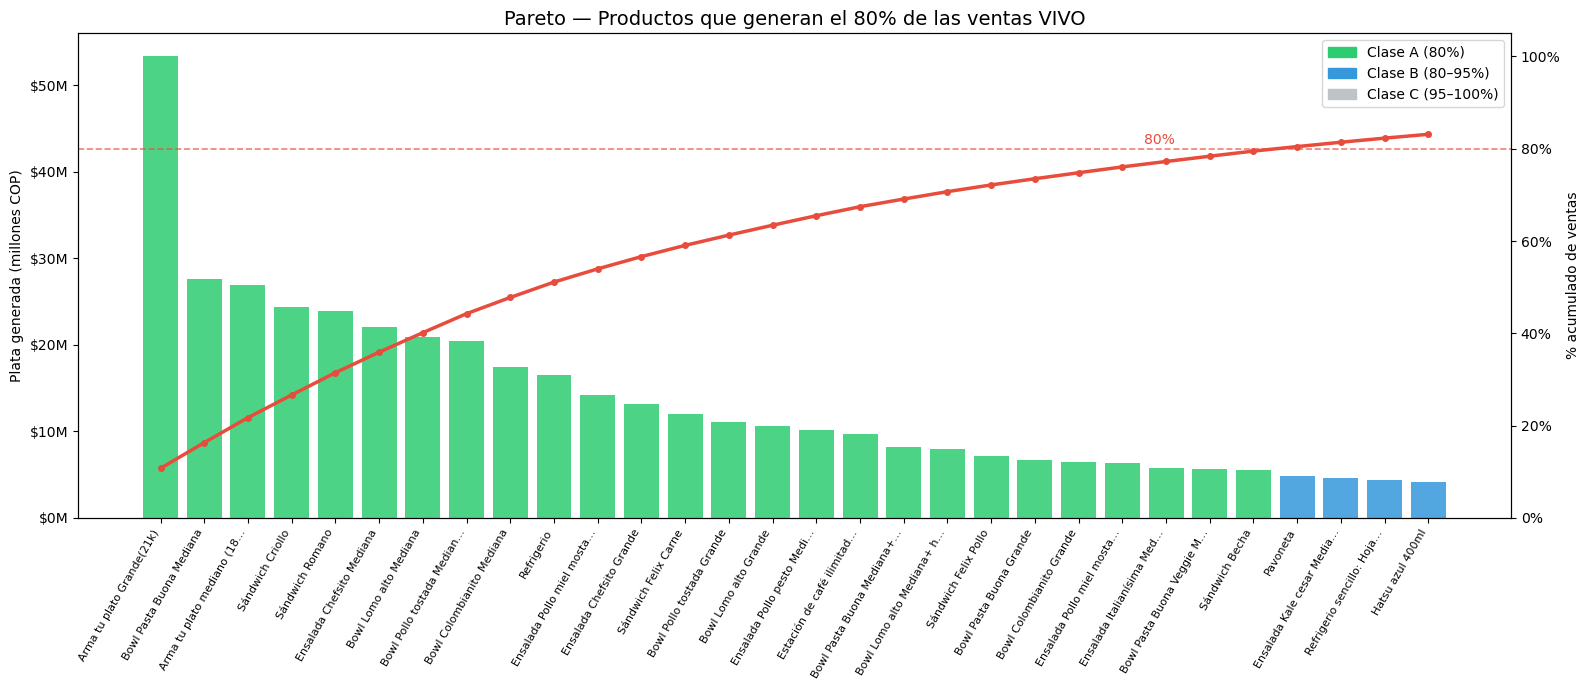


Resumen ABC:
Clase_ABC
C    43
B    31
A    26
Name: count, dtype: int64

Productos Clase A: 26
Plata generada Clase A: $393,890,363


In [ ]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos=info_productos[info_productos["Categoria_Matriz"]=="ESTRELLA (Alto Vol / Alto $)"]
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)



# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────

total = info_productos['Plata generada'].sum()

info_productos['pct']      = info_productos['Plata generada'] / total

info_productos['pct_acum'] = info_productos['pct'].cumsum()



# ── PASO 3: clasificar ABC ────────────────────────────────────────

condiciones = [

    info_productos['pct_acum'] <= 0.80,

    info_productos['pct_acum'] <= 0.95,

]

info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')



# ── PASO 4: graficar ──────────────────────────────────────────────

n_mostrar = min(30, len(info_productos))

df_plot   = info_productos.head(n_mostrar)



colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})



fig, ax1 = plt.subplots(figsize=(16, 7))



# Barras — plata generada

ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)

ax1.set_ylabel('Plata generada (millones COP)')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))



# Línea acumulada (eje derecho)

ax2 = ax1.twinx()

ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de ventas')

ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))



# Etiquetas eje X

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]

ax1.set_xticks(range(n_mostrar))

ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)



# Leyenda

leyenda = [

    Patch(color='#2ecc71', label='Clase A (80%)'),

    Patch(color='#3498db', label='Clase B (80–95%)'),

    Patch(color='#bdc3c7', label='Clase C (95–100%)'),

]

ax1.legend(handles=leyenda, loc='upper right')



plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)

plt.tight_layout()

plt.show()



print(f"\nResumen ABC:")

print(info_productos['Clase_ABC'].value_counts())

print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")

print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


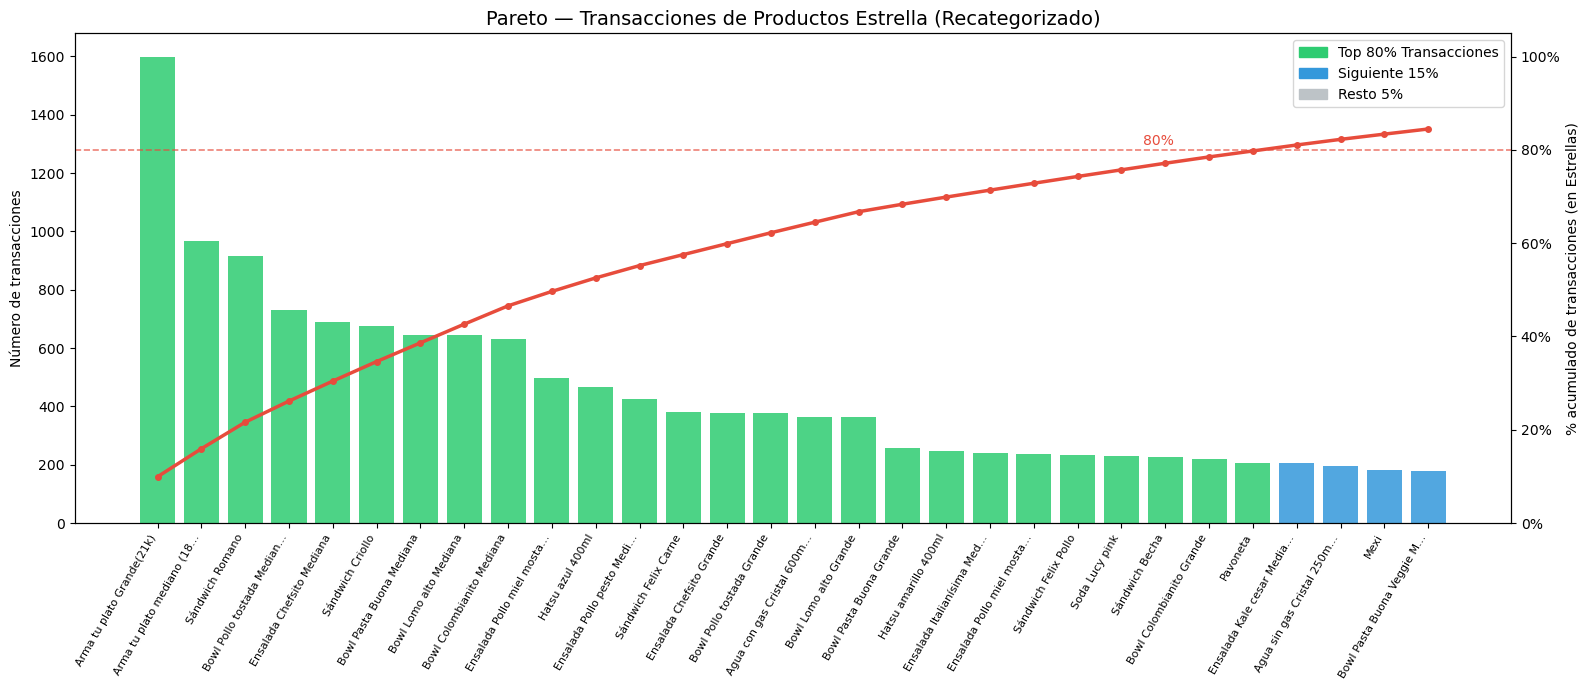

In [ ]:
# 1. Filtrar solo los productos Estrella
df_estrella = info_productos[info_productos["Categoria_Matriz"] == "ESTRELLA (Alto Vol / Alto $)"].copy()

# 2. Ordenar por transacciones de mayor a menor
df_estrella = df_estrella.sort_values('transacciones', ascending=False).reset_index(drop=True)

# 3. Recalcular porcentajes sobre este nuevo total
total_trans_estrella = df_estrella['transacciones'].sum()
df_estrella['pct_trans']      = df_estrella['transacciones'] / total_trans_estrella
df_estrella['pct_trans_acum'] = df_estrella['pct_trans'].cumsum()

# 4. RECATEGORIZAR ABC (Solo para este grupo)
# Esto hará que los más vendidos de este grupo salgan en verde (A)
condiciones_estrella = [
    df_estrella['pct_trans_acum'] <= 0.80,
    df_estrella['pct_trans_acum'] <= 0.95,
]
df_estrella['Clase_ABC_Estrella'] = np.select(condiciones_estrella, ['A', 'B'], default='C')

# 5. Configurar visualización
n_mostrar = min(30, len(df_estrella))
df_plot = df_estrella.head(n_mostrar).copy()
colores = df_plot['Clase_ABC_Estrella'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

# ── GRAFICAR ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de transacciones (en Estrellas)')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [
    Patch(color='#2ecc71', label='Top 80% Transacciones'), 
    Patch(color='#3498db', label='Siguiente 15%'), 
    Patch(color='#bdc3c7', label='Resto 5%')
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Transacciones de Productos Estrella (Recategorizado)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Filtramos el DataFrame original para obtener solo los datos de los productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)]

# 2. Ordenamos para que los más importantes salgan primero en la lista
df_criticos = df_criticos.sort_values('Plata generada', ascending=False)

print(f"Hay {len(productos_criticos)} productos que son Clase A en ambos criterios:\n")

for index, row in df_criticos.iterrows():
    nombre = row['Nombre']
    trans = row['transacciones']
    ventas = row['Plata generada']
    
    # Imprimimos con formato de miles y moneda para que sea profesional
    print(f" - {nombre[:30]:<30} | Transacciones: {int(trans):>4} | Ventas: ${ventas:,.0f}")


Hay 21 productos que son Clase A en ambos criterios:

 - Arma tu plato Grande(21k)      | Transacciones: 1599 | Ventas: $53,315,251
 - Bowl Pasta Buona Mediana       | Transacciones:  646 | Ventas: $27,547,600
 - Arma tu plato mediano (18k)    | Transacciones:  968 | Ventas: $26,857,150
 - Sándwich Criollo               | Transacciones:  674 | Ventas: $24,317,050
 - Sándwich Romano                | Transacciones:  915 | Ventas: $23,931,150
 - Ensalada Chefsito Mediana      | Transacciones:  690 | Ventas: $22,024,000
 - Bowl Lomo alto Mediana         | Transacciones:  646 | Ventas: $20,920,000
 - Bowl Pollo tostada Mediana     | Transacciones:  730 | Ventas: $20,423,500
 - Bowl Colombianito Mediana      | Transacciones:  632 | Ventas: $17,399,200
 - Ensalada Pollo miel mostaza Me | Transacciones:  498 | Ventas: $14,194,900
 - Ensalada Chefsito Grande       | Transacciones:  378 | Ventas: $13,168,600
 - Sándwich Felix Carne           | Transacciones:  380 | Ventas: $12,046,900
 - Bowl Po